In [1]:
import os
import sys
# Add the parent directory to the Python path to allow module imports
sys.path.append(os.path.dirname(os.getcwd()))

# Set random seed for reproducibility
SEED = 42
import random
random.seed(SEED)
import torch
torch.manual_seed(SEED)

import librosa
from matplotlib import pyplot as plt
from pprint import pprint

from modules.datamodule import LungSoundDataModule
from modules.transforms import *

# NOTE: Some classes have very few samples, so we will focus on a subset of classes for the analysis.
SELECTED_CLASSES = [
    "Asthma",
    "Bronchiectasis",
    "Bronchiolitis",
    "COPD",
    "Healthy",
    "Lung Fibrosis",
    "Pneumonia",
    "URTI",
]
  
config = {
    "dataset": {
        "name": "Combined_ICBHI_KAUH",
        "classes": SELECTED_CLASSES,
        "feature_extractor": "STFT",
        "num_channels": 1,
    },
    "batch_size": 16,
    "num_workers": 4,
    "sampler": None,
    "seed": SEED,
}

In [2]:
DATA_FOLDER = os.path.join(os.path.dirname(os.getcwd()), "data/preprocessed")
if not os.path.exists(DATA_FOLDER):
    print(f"Data directory not found at {DATA_FOLDER}. Please ensure the data is downloaded and placed in the correct location.")

In [3]:
def visualize_batch(datamodule: LungSoundDataModule, class_names: list):
    """ Visualize a batch of samples from the dataloader. """
    labels_counter = {class_name: 0 for class_name in class_names}
    dataloader = datamodule.train_dataloader()
    batch_samples, batch_labels, batch_sr = next(iter(dataloader))
    num_rows = len(batch_samples) // 4
    num_cols = len(batch_samples) // num_rows
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(4 * num_cols, 3 * num_rows))
    axes = axes.flatten()
    for i in range(len(batch_samples)):
        sample = batch_samples[i]
        label = batch_labels[i]
        sr = batch_sr[i]
        class_name = class_names[label.item()]
        np_sample = sample.cpu().numpy().squeeze()
        params = datamodule.train_dataset.get_plot_params()
        if np_sample.ndim == 2:  # If the sample is a 2D array (e.g., spectrogram)
            librosa.display.specshow(np_sample, sr=sr, ax=axes[i], **params)
        else:  # If the sample is a 3D array (e.g., RGB image)
            np_sample = np_sample.transpose(1, 2, 0)  # Convert from (C, H, W) to (H, W, C)
            axes[i].imshow(np_sample)
        axes[i].set_title(f"{class_name} (Label: {label.item()})")
        labels_counter[class_name] += 1
    pprint(labels_counter)
    plt.tight_layout()
    plt.show()

{'Asthma': 1,
 'Bronchiectasis': 1,
 'Bronchiolitis': 0,
 'COPD': 11,
 'Healthy': 3,
 'Lung Fibrosis': 0,
 'Pneumonia': 0,
 'URTI': 0}


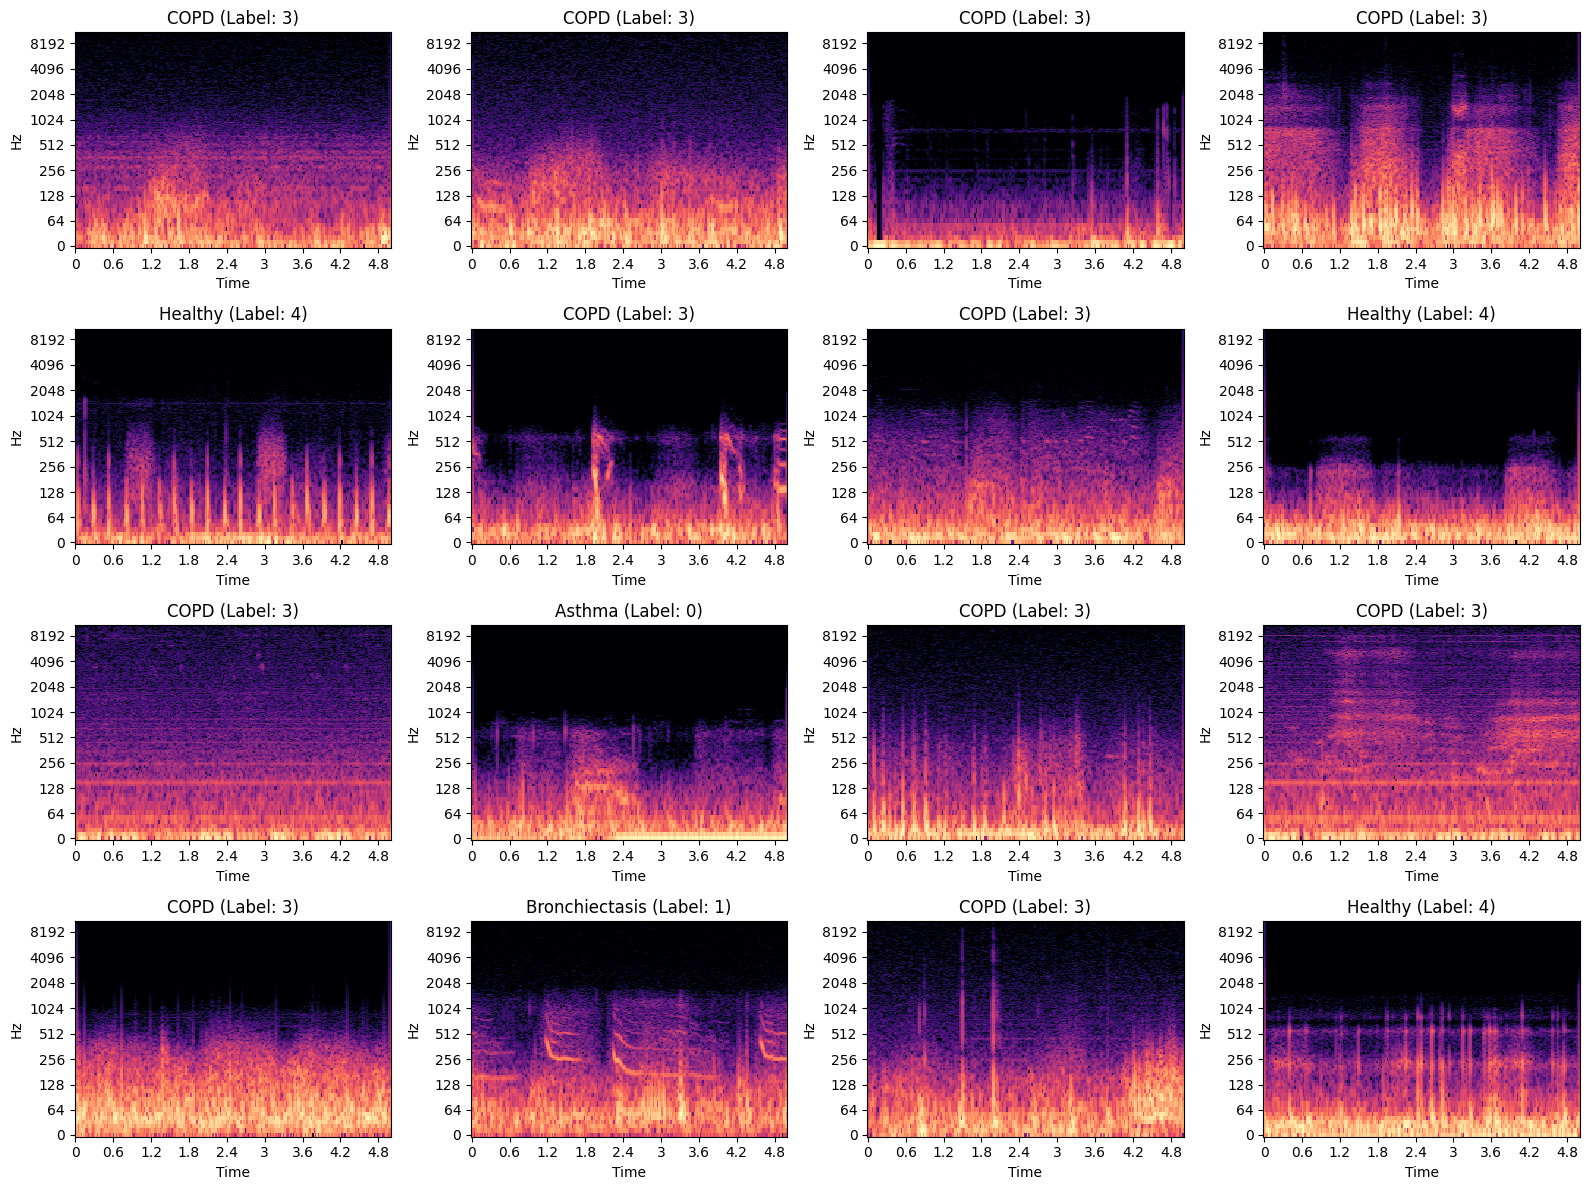

In [4]:
dm = LungSoundDataModule(config, DATA_FOLDER)
dm.setup()
visualize_batch(dm, SELECTED_CLASSES)

{'Asthma': 1,
 'Bronchiectasis': 0,
 'Bronchiolitis': 1,
 'COPD': 1,
 'Healthy': 4,
 'Lung Fibrosis': 3,
 'Pneumonia': 5,
 'URTI': 1}


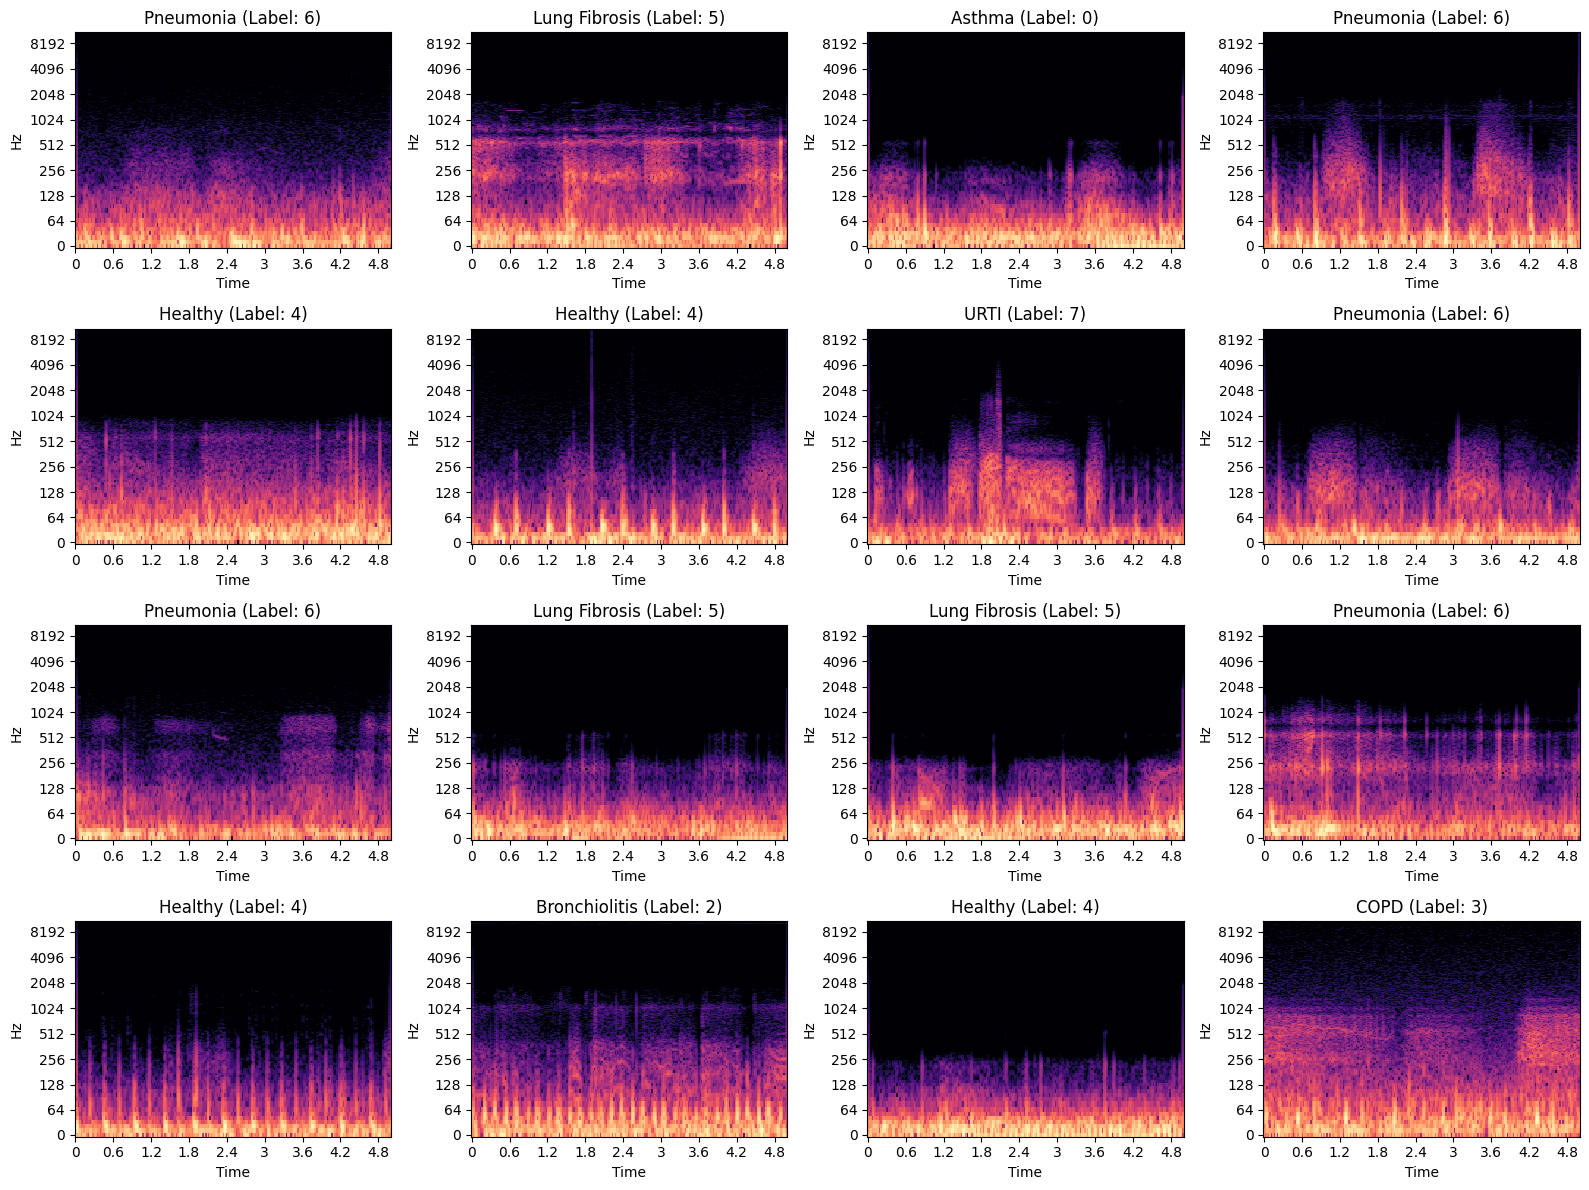

In [5]:
config["sampler"] = "equalizer"
dm = LungSoundDataModule(config, DATA_FOLDER)
dm.setup()
visualize_batch(dm, SELECTED_CLASSES)

{'Asthma': 1,
 'Bronchiectasis': 1,
 'Bronchiolitis': 2,
 'COPD': 0,
 'Healthy': 0,
 'Lung Fibrosis': 6,
 'Pneumonia': 5,
 'URTI': 1}


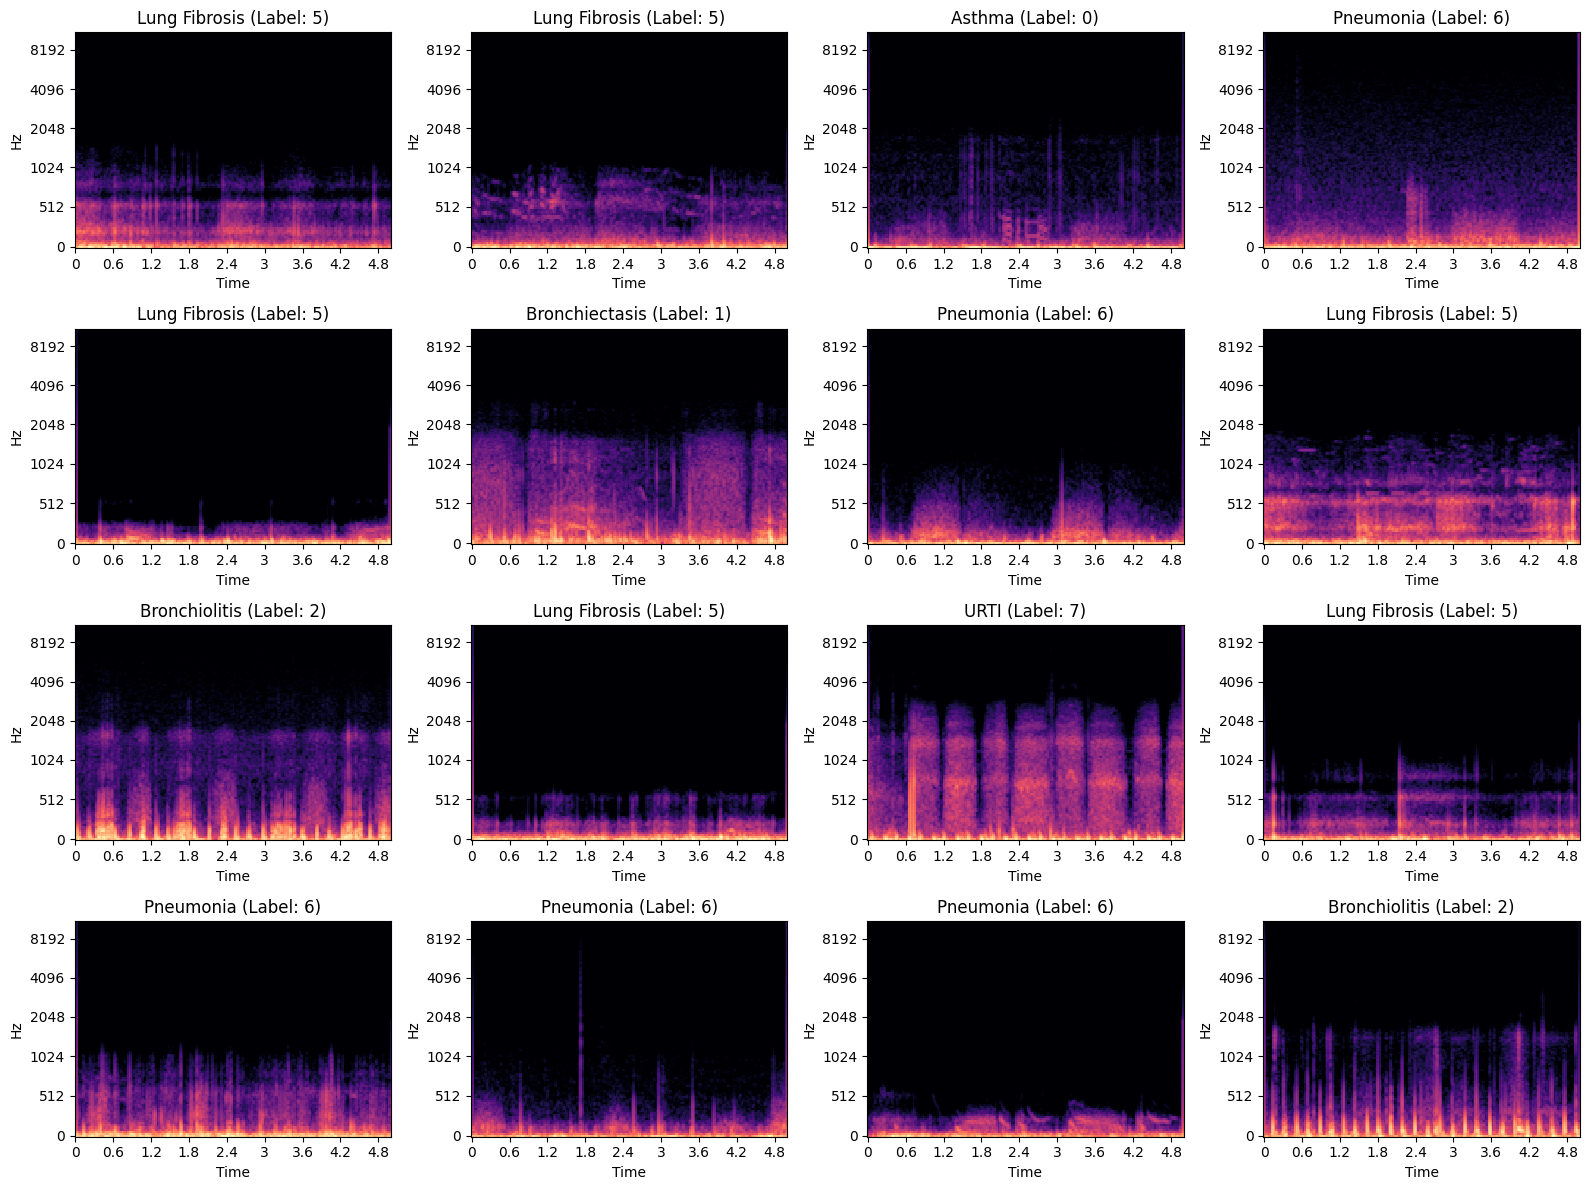

In [6]:
config["dataset"]["feature_extractor"] = "MelSpectrogram"
dm = LungSoundDataModule(config, DATA_FOLDER)
dm.setup()
visualize_batch(dm, SELECTED_CLASSES)

{'Asthma': 3,
 'Bronchiectasis': 2,
 'Bronchiolitis': 1,
 'COPD': 2,
 'Healthy': 0,
 'Lung Fibrosis': 4,
 'Pneumonia': 1,
 'URTI': 3}


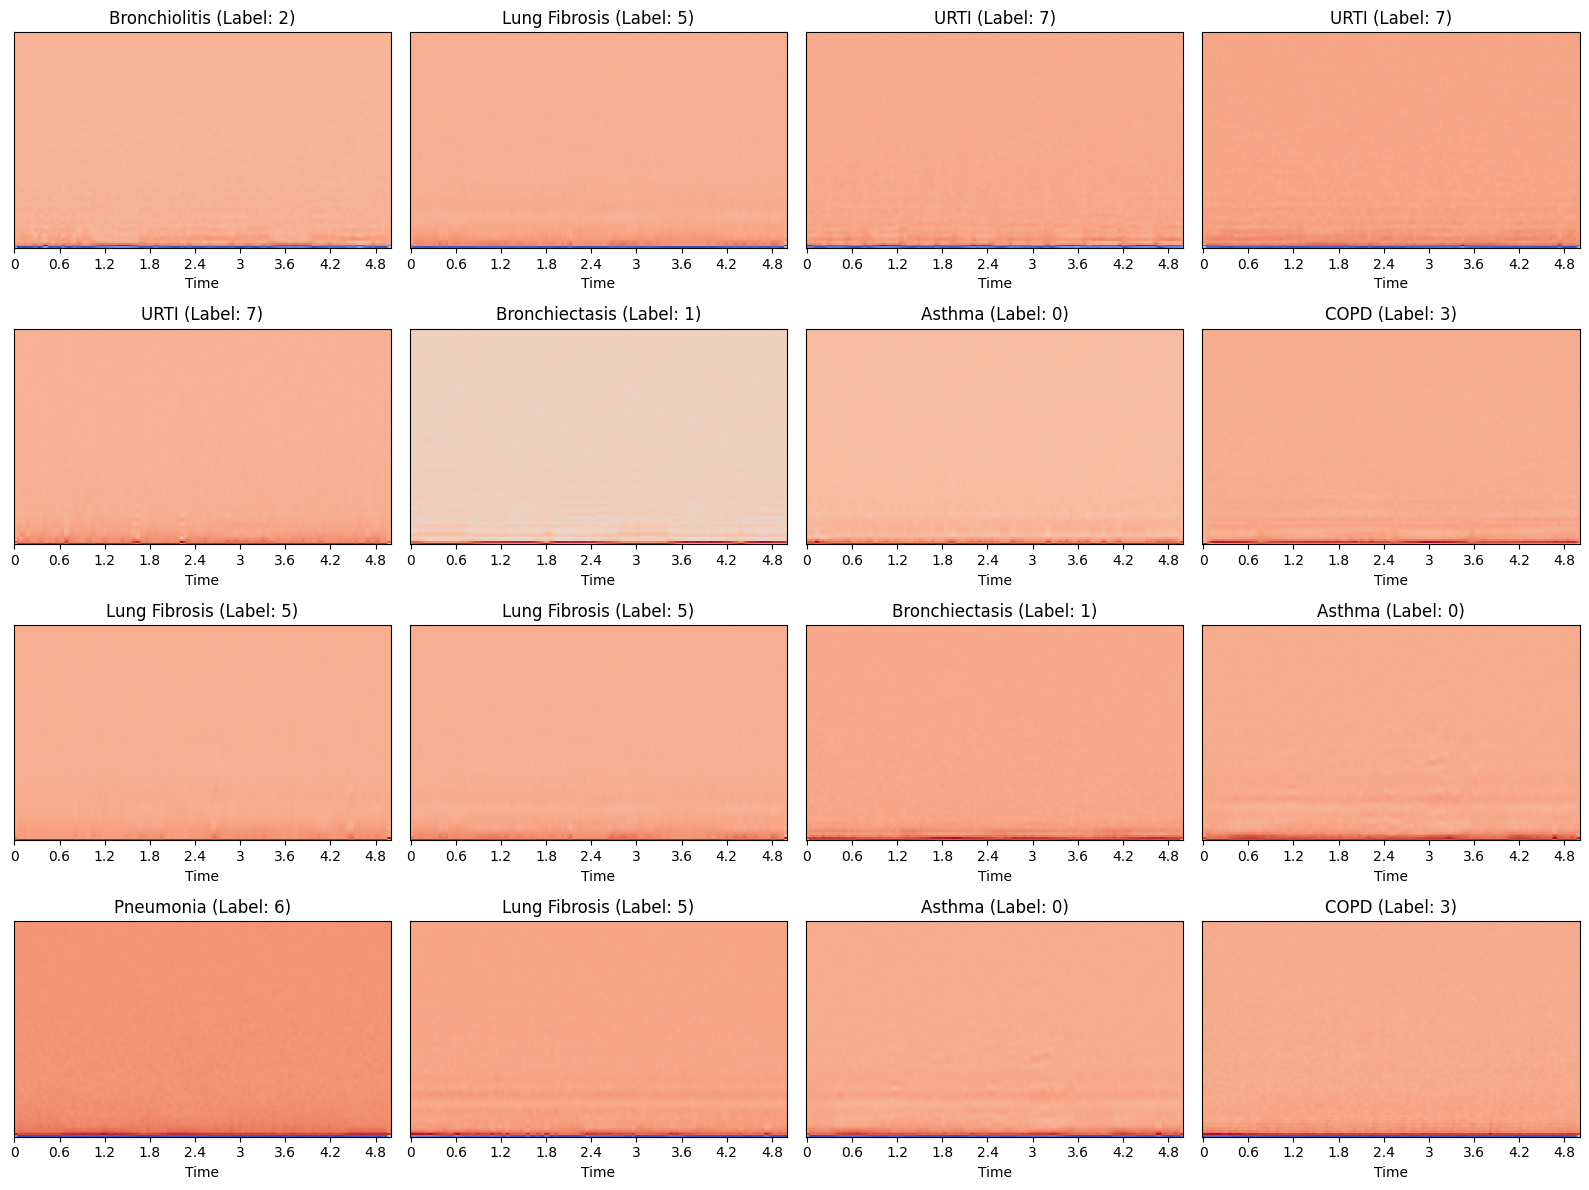

In [7]:
config["dataset"]["feature_extractor"] = "MFCC"
dm = LungSoundDataModule(config, DATA_FOLDER)
dm.setup()
visualize_batch(dm, SELECTED_CLASSES)

{'Asthma': 2,
 'Bronchiectasis': 1,
 'Bronchiolitis': 2,
 'COPD': 5,
 'Healthy': 1,
 'Lung Fibrosis': 1,
 'Pneumonia': 1,
 'URTI': 3}


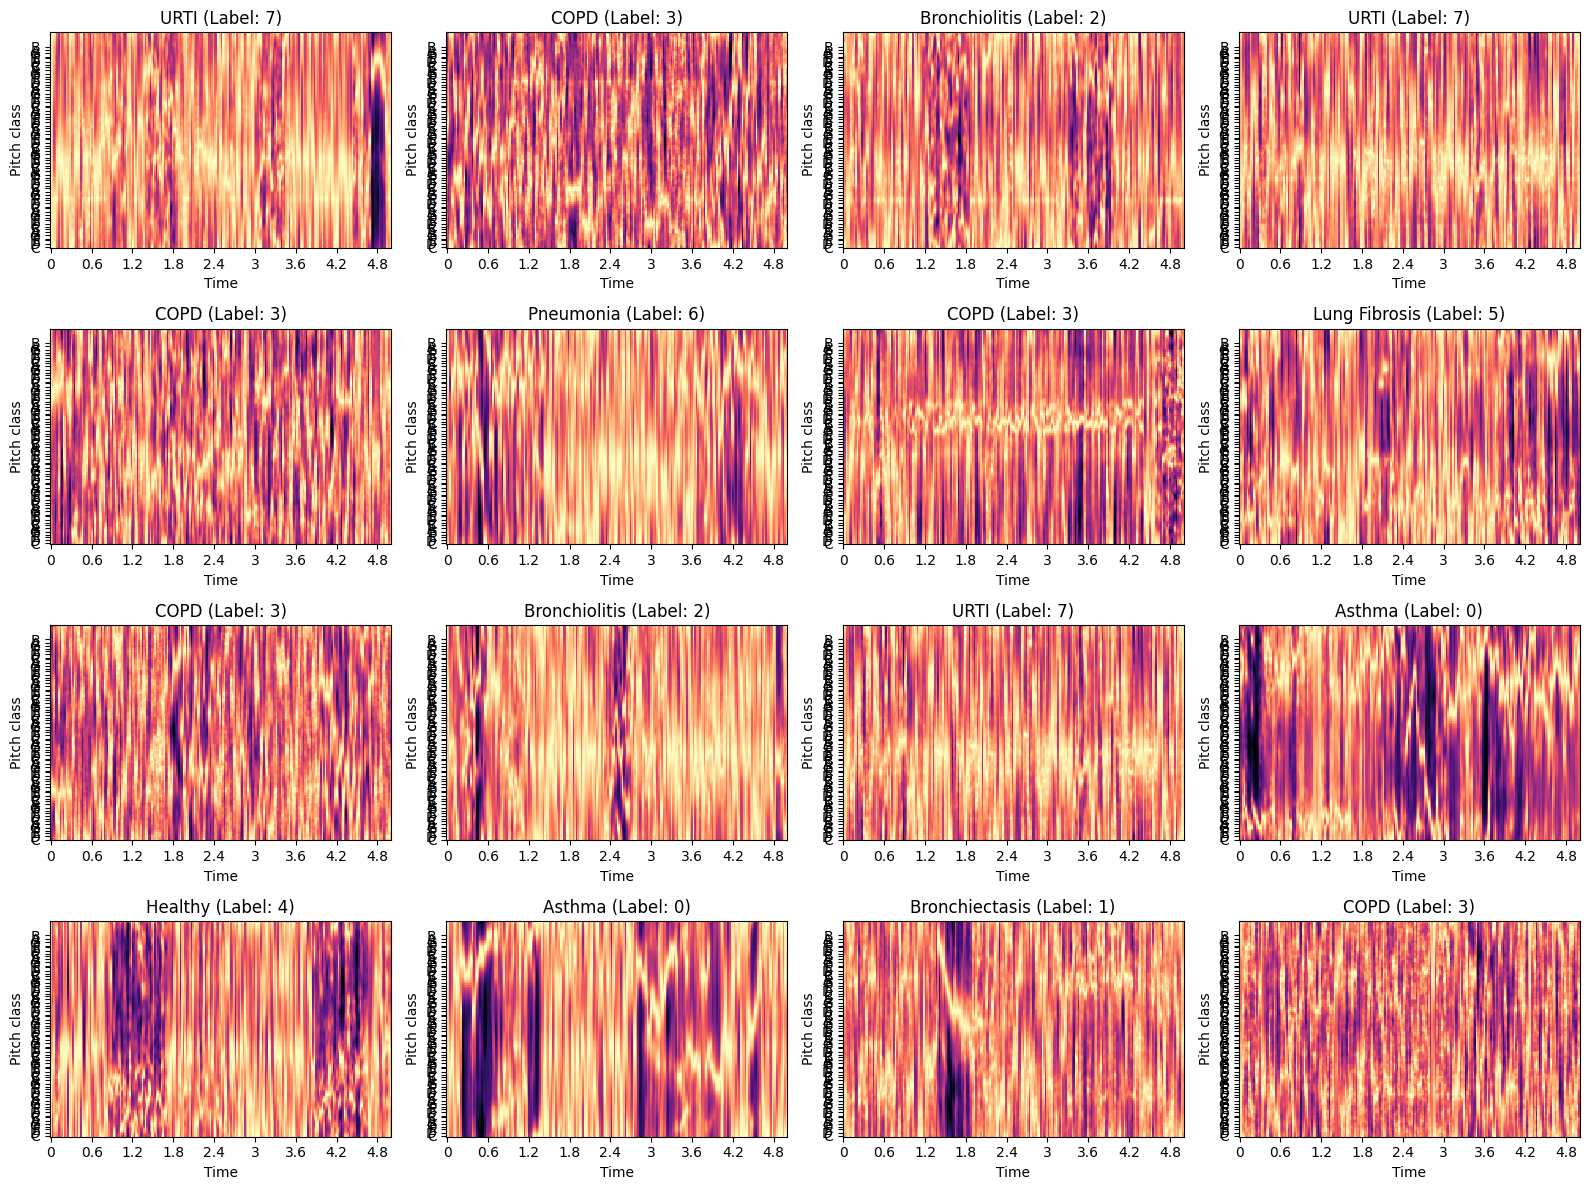

In [8]:
config["dataset"]["feature_extractor"] = "Chroma"
dm = LungSoundDataModule(config, DATA_FOLDER)
dm.setup()
visualize_batch(dm, SELECTED_CLASSES)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-398.40826..233.66309].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-488.20377..92.95761].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-425.46524..185.05328].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-458.25336..188.89908].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-451.93567..189.60239].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-465.41196..124.722824].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-469.2074

{'Asthma': 1,
 'Bronchiectasis': 3,
 'Bronchiolitis': 3,
 'COPD': 3,
 'Healthy': 3,
 'Lung Fibrosis': 1,
 'Pneumonia': 0,
 'URTI': 2}


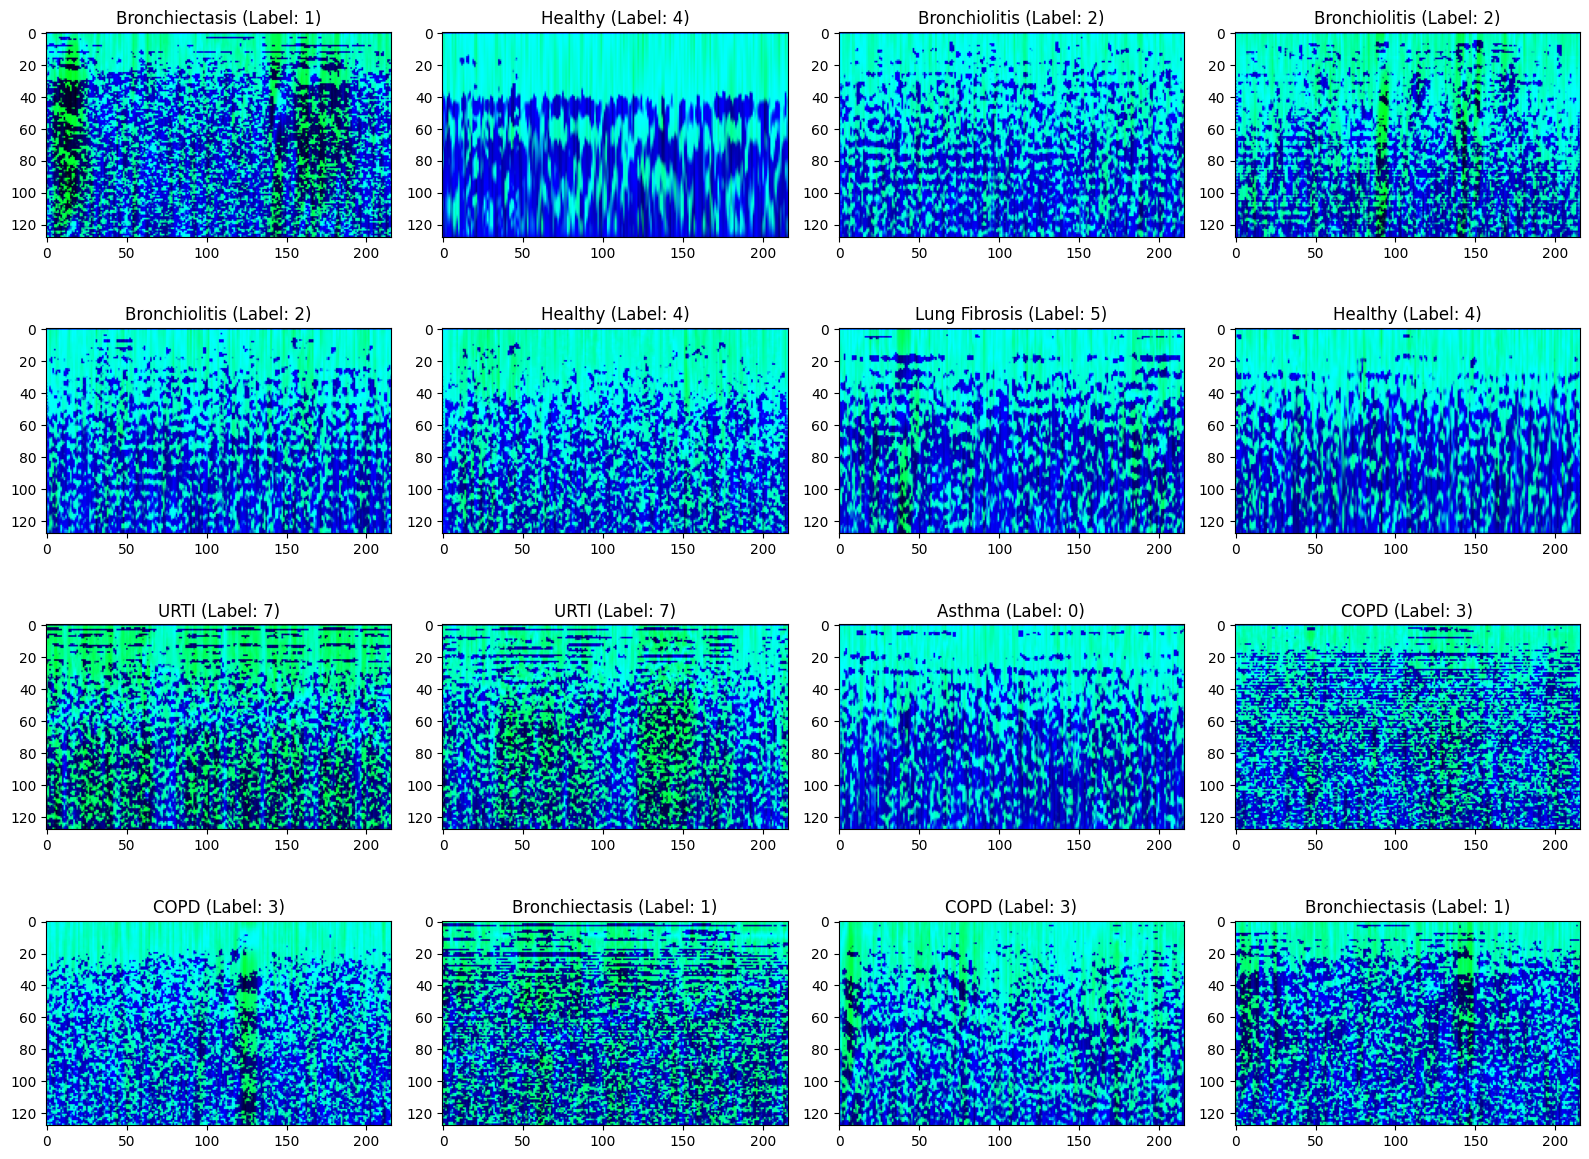

In [9]:
config["dataset"]["feature_extractor"] = "Stack_MelSpectrogram_MFCC_Chroma"
dm = LungSoundDataModule(config, DATA_FOLDER)
dm.setup()
visualize_batch(dm, SELECTED_CLASSES)